# LDA (продолжение)

Здесь мы загрузим исходные данные, лемматизированный текст и словарь. 
На основе этих данных построим модель с разбивкой на 6 тем, оцифруем и попробуем классифицировать
используя различные модели классификации.

In [18]:
import numpy as np
import pandas as pd
from pprint import pprint
import gensim
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim
import matplotlib.pyplot as plt
import csv
import pickle # Для сохранения словаря, корпуса и модели

### 1. Загрузка данных: __data, loaded_text, dictionary, corpus__

####  - исходные данные (__data__)

In [2]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')
data = newsgroups_train.data

In [60]:
data[0]

"From: lerxst@wam.umd.edu (where's my thing)\nSubject: WHAT car is this!?\nNntp-Posting-Host: rac3.wam.umd.edu\nOrganization: University of Maryland, College Park\nLines: 15\n\n I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.\n\nThanks,\n- IL\n   ---- brought to you by your neighborhood Lerxst ----\n\n\n\n\n"

#### - лемматизированный текст (__loaded_text__) 

In [3]:
with open('lemmatized_txt.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    # next(reader)  # Пропуск заголовка, если при записи мы его вставили: 
    loaded_text = [row[0] for row in reader]
    
    # with open('lemmatized_text.csv', 'w', newline='', encoding='utf-8') as f:
        # writer = csv.writer(f)
        # writer.writerow(['word'])  # Заголовок
        # for word in lemmatized_text:
            # writer.writerow([word])

In [6]:
loaded_text[:2]

["['lerxst', 'wam_umd', 'thing', 'car', 'nntp_posting', 'host', 'rac_wam', 'umd', 'organization', 'university', 'maryland_college', 'park', 'line', 'wonder', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sport', 'car', 'look', 'late', 'early', 'call', 'bricklin', 'door', 'really', 'small', 'addition', 'front_bumper', 'separate', 'rest', 'body', 'know', 'anyone', 'tellme', 'model', 'name', 'engine', 'spec', 'year', 'production', 'car', 'make', 'history', 'whatever', 'info', 'funky', 'look', 'car', 'please', 'mail', 'thanks', 'il', 'bring', 'neighborhood', 'lerxst']",
 "['guykuo_carson', 'washington', 'guy_kuo', 'si', 'clock', 'poll', 'final', 'call', 'summary', 'final', 'call', 'si', 'clock', 'report', 'keywords', 'si', 'acceleration', 'clock', 'upgrade', 'article', 'shelley', 'qvfo', 'innc', 'organization', 'university', 'washington', 'line', 'nntp_posting', 'host', 'carson_washington', 'fair', 'number', 'brave', 'soul', 'upgrade', 'si', 'clock', 'oscillator', 'share', 

#### - словарь (__dictionary__)

In [5]:
dictionary = corpora.Dictionary.load('dictionary.dict')

In [ ]:
pprint(dictionary.token2id)

#### - корпус (__corpus__)

In [9]:
with open('corpus.pkl', 'rb') as f:
    corpus = pickle.load(f)

In [61]:
print(type(corpus))
print(corpus[0])

<class 'list'>
[(0, 1), (1, 2), (2, 1), (3, 1), (4, 1), (5, 1), (6, 5), (7, 1), (8, 1), (9, 2), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 2), (22, 1), (23, 2), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1)]


### 2. Построение тематической модели LDA на 6 тем (<font color='lightgreen'>lda_model</font>)

In [11]:
from gensim.models import LdaModel

In [12]:
lda_model = gensim.models.ldamodel.LdaModel(
   corpus=corpus, id2word=dictionary, num_topics=6, random_state=101, 
   update_every=1, chunksize=100, passes=10, alpha='auto', per_word_topics=True
)
# Пояснения к задаваемым параметрам
# update_every - определяет частоту обновления модели.
      # 1 — модель обновляется после каждого прохода по части корпуса (chunksize документов).
      # 0 — модель обновляется после полного прохода по всему корпусу.
# chunksize - количество документов, обрабатываемых за один раз. Используется для оптимизации памяти.
# passes - количество полных проходов (итераций) по корпусу. Чем больше значение, тем лучше модель успевает адаптироваться к данным, но обучение становится дольше.
# alpha - (строка или список): гиперпараметр распределения Дирихле для распределения документов по темам.
      # 'auto' — модель автоматически подбирает оптимальное значение.
      # Фиксированные значения (например, 0.01) задают степень сглаживания.
# per_word_topics - (True/False): True - модель дополнительно сохраняет распределение тем для каждого слова в документе. 
# Это полезно для анализа влияния слов на темы

In [ ]:
pprint(lda_model.print_topics())

In [14]:
# Какие темы мы получили
# Названий нет, в каждой теме набор слов, с вероятностями их встретить в данной теме
topics=lda_model.show_topics(num_topics=6, num_words=10,formatted=False)
print(type(topics)) # class - list
print(len(topics))

print(topics[1]) # конкретная тема (номер темы, слова, вероятности)
print(topics[1][1][:3]) # в конкретной теме только слова (выборочные - [:3])
# topics

<class 'list'>
6
(1, [('ax', 0.19917493), ('max', 0.016739655), ('c_', 0.007918042), ('ei', 0.007848205), ('cx', 0.0063387896), ('dn', 0.0062815943), ('um', 0.005911204), ('pa', 0.0054686675), ('em', 0.005039497), ('lk', 0.0046782945)])
[('ax', 0.19917493), ('max', 0.016739655), ('c_', 0.007918042)]


In [21]:
topics_words = [(tp[0], [wd[0] for wd in tp[1]]) for tp in topics]
#Below Code Prints Only Words
for topic, words in topics_words:
    print("topic_{}: ".format(topic)+" ".join(words))

topic_0: com line organization get article write would like one university
topic_1: ax max c_ ei cx dn um pa em lk
topic_2: system use line key program file drive com window organization
topic_3: team game player win play year season score nhl la
topic_4: people would say government state israel gun right one make
topic_5: god say people one evidence reason believe christian think would


#### 2а.Оценка сложности модели -> <font color='lightgreen'>lda_model.log_perplexity(corpus)</font> и когерентности вычислений -> <font color='lightgreen'>CoherenceModel(...)</font>

In [16]:
print('\nPerplexity: ', lda_model.log_perplexity(corpus))


Perplexity:  -8.82308278483206


In [17]:
from gensim.models import CoherenceModel
coherence_model_lda = CoherenceModel(
 model=lda_model, texts=loaded_text, dictionary=dictionary, coherence='c_v'
)
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)

c:\Users\shaps\anaconda3\Lib\site-packages\gensim\topic_coherence\direct_confirmation_measure.py:204: RuntimeWarning: divide by zero encountered in scalar divide
  m_lr_i = np.log(numerator / denominator)
c:\Users\shaps\anaconda3\Lib\site-packages\gensim\topic_coherence\indirect_confirmation_measure.py:323: RuntimeWarning: invalid value encountered in scalar divide
  return cv1.T.dot(cv2)[0, 0] / (_magnitude(cv1) * _magnitude(cv2))



Coherence Score:  nan


#### 2б. Визуализация тем-ключевые слова -> <font color='lightgreen'>pyLDAvis.gensim.prepare(...)</font>

In [20]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.173802 -0.019311       1        1  38.812765
2      0.063282 -0.166089       2        1  19.069223
4      0.160711  0.064823       3        1  16.491065
5      0.177027  0.018952       4        1  13.574859
1     -0.350047 -0.183091       5        1   7.792898
3     -0.224774  0.284716       6        1   4.259190, topic_info=          Term          Freq         Total Category  logprob  loglift
6428        ax  28218.000000  28218.000000  Default  30.0000  30.0000
756        god   4152.000000   4152.000000  Default  29.0000  29.0000
2789       max   2372.000000   2372.000000  Default  28.0000  28.0000
223        com  13715.000000  13715.000000  Default  27.0000  27.0000
1054      team   1763.000000   1763.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
228   division    245.805550    560.865767   Topic6  -5.7526   2.3312
625       lose    249.281921    952.560675   Topic6  -5.7385   1.8155
690         st    254.780075   1140.731957   Topic6  -5.7167   1.6571
368      first    274.340915   2991.873562   Topic6  -5.6428   0.7668
467       last    246.739291   1702.369715   Topic6  -5.7488   1.2246

[384 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
8836      4  0.998445  aa_freenet
2020      1  0.997991      advice
9872      3  0.995877         aid
4851      2  0.997548   algorithm
9790      6  0.991709      alomar
...     ...       ...         ...
51        1  0.565303        year
51        3  0.249669        year
51        4  0.001840        year
51        6  0.183178        year
7198      5  0.996226          zd

[627 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 3, 5, 6, 2, 4])

### 3. Сохранение модели -> <u>save:</u> <font color='orange'>'lda_model_6.model.model'</font>

In [22]:
lda_model.save('lda_model_6.model')

### 4. Перевод в дата фрейм

In [ ]:
topic_distributions = [lda_model.get_document_topics(doc) for doc in corpus]
    
    # возвращает список списков (11314), где в каждом внутреннем списке
    # кортеж из пар (topic_id, probability), (topic_id, probability), ...
    # где topic_id — индекс темы, 
    # probability — вероятность того, что документ относится к данной теме. 

In [29]:
# len(topic_distributions) # 11314
# type(topic_distributions[1])
# lda_model.num_topics # 6

list

In [31]:
# Преобразование распределений в табличный формат
# Каждый документ представлен вектором вероятностей для тем
topic_matrix = np.zeros((len(topic_distributions), lda_model.num_topics))
# topic_matrix
for i, doc_topics in enumerate(topic_distributions):
    for topic_id, prob in doc_topics:
        topic_matrix[i, topic_id] = prob

Как работает.  
1. Внешний цикл.  
   - в i - номер документа,  
   - в  doc_topics - список кортежей вида (№ темы, вероятность).  
   - т.к. тем - 25 - то и кортежей 25.
На первом проходе берем номер темы и список кортежей.  
1. Внутренний цикл.  
    - проходимся поочередно по 25 кортежам вытаскивая № темы и вероятность.  
    - в заготовленную матрицу заносим вероятность на позицию: 
        - № строки  = i - номер документа,
        - № столбца = topic_id - номер темы.



In [32]:
topic_df = pd.DataFrame(topic_matrix, columns=[f"Topic {i}" for i in range(lda_model.num_topics)])
topic_df.head()

,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
0,0.968958,0.0,0.014516,0.0,0.000000,0.000000
1,0.212314,0.0,0.565954,0.0,0.171497,0.048385
2,0.697659,0.0,0.211119,0.0,0.011300,0.078922
3,0.784078,0.0,0.203694,0.0,0.000000,0.000000
4,0.713696,0.0,0.227004,0.0,0.000000,0.053323


#### Определяем номер темы, к которой документ относится с нааибольшей вероятностью

In [33]:
topic_df['Dominant Topic'] = topic_df.idxmax(axis=1)

Что делает idxmax(axis=1):
    - вычисляет индекс столбца с максимальным значением (для каждой строки, т.е. для каждого документа).
    - axis=1 указывает, что операция выполняется по строкам.
Возвращает название столбца (например, Topic 0, Topic 1, ...) с максимальной вероятностью для каждой строки.

В итоге добавляется еще одиин столбец - 'Dominant Topic'

In [34]:
topic_df.head()

,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Dominant Topic
0,0.968958,0.0,0.014516,0.0,0.000000,0.000000,Topic 0
1,0.212314,0.0,0.565954,0.0,0.171497,0.048385,Topic 2
2,0.697659,0.0,0.211119,0.0,0.011300,0.078922,Topic 0
3,0.784078,0.0,0.203694,0.0,0.000000,0.000000,Topic 0
4,0.713696,0.0,0.227004,0.0,0.000000,0.053323,Topic 0


Подсчитаем количество документов по доминирующим темам


In [35]:
topic_counts = topic_df['Dominant Topic'].value_counts()

In [36]:
topic_counts

Dominant Topic
Topic 0    6247
Topic 2    2440
Topic 5    1237
Topic 4    1195
Topic 3     173
Topic 1      22
Name: count, dtype: int64

### 5. Решаем задачу классификации -> на входе <font color='orange'>topic_df</font>

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split

In [38]:
X = topic_df.drop('Dominant Topic', axis=1)
y = topic_df['Dominant Topic']

In [39]:
#разделим данные на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [41]:
log_model_raw = LogisticRegression(solver='saga', max_iter=5000)
log_model = OneVsRestClassifier(log_model_raw)

penalty = ['l2','elasticnet'] # вариант: penalty = ['l1', 'l2', 'elasticnet']
l1_ratio = np.linspace(0, 1, 10)
C = np.logspace(0, 10, 5)
param_grid = {'estimator__penalty': penalty,
              'estimator__l1_ratio': l1_ratio,
              'estimator__C': C
              }

# cv=5 - при кросс валидации данные будут разбиты на 5 частей
# n_jobs=-1 - будут задействованы все ядра процессора на машине
grid_model = GridSearchCV(estimator=log_model,  param_grid=param_grid, cv=5, n_jobs=-1)

In [42]:
grid_model.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=OneVsRestClassifier(estimator=LogisticRegression(max_iter=5000,
                                                                        solver='saga')),
             n_jobs=-1,
             param_grid={'estimator__C': array([1.00000000e+00, 3.16227766e+02, 1.00000000e+05, 3.16227766e+07,
       1.00000000e+10]),
                         'estimator__l1_ratio': array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
                         'estimator__penalty': ['l2', 'elasticnet']})

### Сохраним модель

In [53]:
import joblib

# Сохранение модели
joblib.dump(grid_model, 'grid_model.pkl')

# Загрузка модели
# loaded_model = joblib.load('grid_model.pkl')

# Использование загруженной модели
# y_pred = loaded_model.predict(X_test)

['grid_model.pkl']

### 5. Оценим качество классификации -> на входе модель <font color='orange'>grid_model</font>

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [44]:
grid_model.best_params_

{'estimator__C': 316.22776601683796,
 'estimator__l1_ratio': 0.6666666666666666,
 'estimator__penalty': 'elasticnet'}

In [48]:
round(C[3],2)

31622776.6

In [49]:
y_pred = grid_model.predict(X_test)

In [50]:
print(accuracy_score(y_test, y_pred))

0.9883351007423118


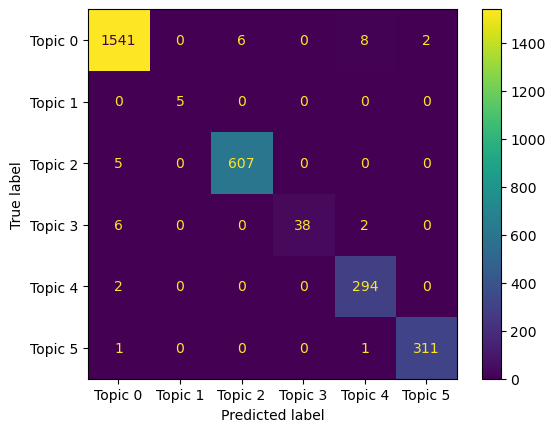

In [52]:
ConfusionMatrixDisplay.from_estimator(grid_model, X_test, y_test)

In [54]:
print(confusion_matrix(y_test, y_pred))

[[1541    0    6    0    8    2]
 [   0    5    0    0    0    0]
 [   5    0  607    0    0    0]
 [   6    0    0   38    2    0]
 [   2    0    0    0  294    0]
 [   1    0    0    0    1  311]]


In [55]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

     Topic 0       0.99      0.99      0.99      1555
     Topic 1       1.00      1.00      1.00         5
     Topic 2       0.99      0.99      0.99       613
     Topic 3       0.83      1.00      0.90        38
     Topic 4       0.99      0.96      0.98       305
     Topic 5       0.99      0.99      0.99       313

    accuracy                           0.99      2829
   macro avg       0.97      0.99      0.98      2829
weighted avg       0.99      0.99      0.99      2829



In [63]:
print(y_pred[10:20])
print(y_test[10:20])

['Topic 2' 'Topic 0' 'Topic 2' 'Topic 0' 'Topic 4' 'Topic 0' 'Topic 0'
 'Topic 0' 'Topic 0' 'Topic 0']
6641     Topic 2
7599     Topic 0
7246     Topic 2
625      Topic 0
4004     Topic 4
2897     Topic 0
10392    Topic 0
11233    Topic 0
1825     Topic 0
218      Topic 0
Name: Dominant Topic, dtype: object


In [75]:
print(grid_model.predict(X_test)[0], y_test[0])

Topic 5 Topic 0


In [76]:
print(X_test.loc[0])
print(y_test[0])

Topic 0    0.968958
Topic 1    0.000000
Topic 2    0.014516
Topic 3    0.000000
Topic 4    0.000000
Topic 5    0.000000
Name: 0, dtype: float64
Topic 0


### Подача на вход нового документа и оценка вероятности отнесения его к определенной теме (см. файл <font color='orange'>predict.ipynb</font>)